# Chấm điểm ưu tiên: So sánh 3 chiến lược xác định khách hàng cần can thiệp

**Bài toán kinh doanh** (cùng bối cảnh với [`01_eda_business_insights.ipynb`](01_eda_business_insights.ipynb)): một doanh nghiệp Fintech/E-commerce đang đối mặt

1. **CAC tăng** — mỗi khách hàng mới ngày càng tốn kém hơn để thu hút
2. **Churn tập trung ở nhóm khách hàng giá trị** — những khách hàng đáng giữ nhất lại đang rời đi
3. **Chiến dịch giữ chân bị mass-marketing** — voucher gửi đại trà cho toàn bộ khách hàng, lãng phí ngân sách cho người chắc chắn ở lại (hoặc chắc chắn rời đi) dù có can thiệp hay không, và gây phiền hà cho phần còn lại

Notebook EDA đã định lượng cả ba vấn đề. Notebook này trả lời câu hỏi tiếp theo: **chọn top 20% khách hàng ưu tiên bằng cách nào?**

Có nhiều cách hợp lý để định nghĩa "ưu tiên", và mỗi cách nhìn vào một khía cạnh khác nhau của hành vi khách hàng. Notebook này xây dựng và so sánh **3 chiến lược** (đúng theo cách tiếp cận đã thử nghiệm trong `customer_analysis.ipynb`):

1. **Xác suất churn cao (mô hình phân loại)** — LightGBM, cùng phương pháp stacked-cohort/OOT đã dùng trong `docs/model_card_churn.md`.
2. **P(alive) thấp (BG-NBD)** — mô hình xác suất "còn sống" dựa trên tần suất và độ mới của giao dịch (Beta-Geometric/NBD).
3. **CLV cao × rủi ro churn cao (Survival-based)** — kết hợp giá trị còn lại kỳ vọng (Survival Analysis + Gamma-Gamma) với xác suất churn trong ngắn hạn.

Sau khi so sánh, notebook **chọn một chiến lược dựa trên dữ liệu thực tế** (không phải cảm tính), rồi dùng danh sách top 20% của chiến lược đó để mô phỏng ROI chiến dịch với thiết kế holdout/control-group.

**Mọi giả định dùng để mô phỏng phản hồi chiến dịch (chi phí mỗi lượt tiếp cận, hiệu ứng can thiệp) đều được nêu rõ và chỉ mang tính minh hoạ** — bộ dữ liệu này chưa có dữ liệu phản hồi chiến dịch thật.

In [1]:
%matplotlib inline
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lightgbm import LGBMClassifier
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import roc_auc_score
from lifetimes import BetaGeoFitter, GammaGammaFitter
from lifetimes.utils import summary_data_from_transaction_data
from lifelines import WeibullAFTFitter
from lifelines.utils import concordance_index

from src.feature_engineering import (
    FEATURE_COLUMNS,
    build_churn_training_dataset_stacked,
    build_survival_training_dataset,
    compute_customer_value_proxy,
)

plt.rcParams["figure.dpi"] = 100
np.random.seed(42)

INACTIVITY_WINDOW = 30

customers = pd.read_csv("../data/customers.csv", index_col=0)
transactions = pd.read_csv("../data/transactions.csv", index_col=0)
customers["signup_date"] = pd.to_datetime(customers["signup_date"])
transactions["transaction_date"] = pd.to_datetime(transactions["transaction_date"])
print(f"Số giao dịch: {len(transactions):,}, khoảng thời gian {transactions['transaction_date'].min().date()} -> {transactions['transaction_date'].max().date()}")


Số giao dịch: 72,238, khoảng thời gian 2025-01-03 -> 2026-07-11


## 1. Xây dựng 3 mô hình

Cả 3 mô hình dùng **chung một snapshot** (cùng ngày "chụp ảnh" dữ liệu) để đảm bảo so sánh công bằng — đây là cohort gần nhất từ tập stacked-cohort, đồng thời là tập khách hàng hiện tại cần chấm điểm cho chiến dịch.

In [2]:
stacked = build_churn_training_dataset_stacked(transactions, INACTIVITY_WINDOW, snapshot_freq_days=30, min_history_days=90)

oot_snapshot = stacked["snapshot_date"].max()
oot = stacked[stacked["snapshot_date"] == oot_snapshot].copy()
pool = stacked[stacked["snapshot_date"] != oot_snapshot]

print(f"Snapshot dùng chung cho cả 3 mô hình: {oot_snapshot.date()}")
print(f"Số khách hàng cần chấm điểm: {len(oot):,}, tỷ lệ churn thực tế (30 ngày sau snapshot): {oot['churn'].mean():.1%}")


Snapshot dùng chung cho cả 3 mô hình: 2026-05-28
Số khách hàng cần chấm điểm: 3,234, tỷ lệ churn thực tế (30 ngày sau snapshot): 47.2%


### 1.1. Chiến lược 1 — Xác suất churn cao (mô hình phân loại)

LightGBM huấn luyện theo stacked-cohort, kiểm định out-of-time — cùng mô hình đã tài liệu hoá trong `docs/model_card_churn.md`.

In [3]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, intime_idx = next(gss.split(pool, groups=pool["customer_id"]))
train_df, intime_df = pool.iloc[train_idx], pool.iloc[intime_idx]

neg, pos = (train_df["churn"] == 0).sum(), (train_df["churn"] == 1).sum()
clf = LGBMClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=3, random_state=42,
    n_jobs=-1, scale_pos_weight=neg / pos, verbosity=-1,
)
clf.fit(train_df[FEATURE_COLUMNS], train_df["churn"])

oot_auc = roc_auc_score(oot["churn"], clf.predict_proba(oot[FEATURE_COLUMNS])[:, 1])
oot["churn_proba"] = clf.predict_proba(oot[FEATURE_COLUMNS])[:, 1]
print(f"Mô hình phân loại — ROC-AUC ngoài mẫu (OOT): {oot_auc:.4f}")


Mô hình phân loại — ROC-AUC ngoài mẫu (OOT): 0.7883


### 1.2. Chiến lược 2 — P(alive) thấp (BG-NBD)

Mô hình Beta-Geometric/NBD (thư viện `lifetimes`) ước lượng xác suất một khách hàng "còn sống" (còn là khách hàng active) dựa trên tần suất và độ mới của các giao dịch trong quá khứ — một góc nhìn xác suất khác với mô hình phân loại, không cần nhãn churn để huấn luyện.

In [4]:
txns_upto_snapshot = transactions[transactions["transaction_date"] <= oot_snapshot]
bgnbd_summary = summary_data_from_transaction_data(
    txns_upto_snapshot, customer_id_col="customer_id", datetime_col="transaction_date",
    monetary_value_col="amount", observation_period_end=oot_snapshot,
)

bgf = BetaGeoFitter(penalizer_coef=0.001)
bgf.fit(bgnbd_summary["frequency"], bgnbd_summary["recency"], bgnbd_summary["T"])
bgnbd_summary["p_alive"] = bgf.conditional_probability_alive(
    bgnbd_summary["frequency"], bgnbd_summary["recency"], bgnbd_summary["T"]
)

oot = oot.merge(bgnbd_summary[["p_alive"]].reset_index(), on="customer_id", how="left")
oot["p_alive"] = oot["p_alive"].fillna(0.0)  # không có lịch sử giao dịch trước snapshot -> coi như rủi ro cao nhất
print(f"BG-NBD — P(alive) trung bình: {oot['p_alive'].mean():.3f}, trung vị: {oot['p_alive'].median():.3f}")


BG-NBD — P(alive) trung bình: 0.910, trung vị: 0.994


### 1.3. Chiến lược 3 — CLV cao × rủi ro churn cao (Survival-based)

Kết hợp hai mảnh: **(a)** xác suất churn trong 30 ngày tới, ước lượng bằng mô hình Survival (Weibull AFT trên `frequency` và `avg_amount`, cùng bộ covariate với `Survival_model` production); **(b)** giá trị còn lại kỳ vọng, ước lượng bằng thời gian sống còn lại kỳ vọng (đã chiết khấu) nhân với giá trị đơn hàng trung bình kỳ vọng (Gamma-Gamma). Điểm số cuối = `log1p(giá trị còn lại kỳ vọng) × xác suất churn 30 ngày` — khách hàng vừa có giá trị lớn vừa có rủi ro cao mới được ưu tiên cao.

In [5]:
surv_data = build_survival_training_dataset(customers, transactions, INACTIVITY_WINDOW, snapshot_date=oot_snapshot)

surv_features = ["frequency", "avg_amount"]
raft = WeibullAFTFitter()
raft.fit(surv_data[surv_features + ["duration", "event"]], duration_col="duration", event_col="event")

expected_survival_time = raft.predict_expectation(surv_data[surv_features])  # cùng chiều với "thời gian đến sự kiện" -> không đảo dấu khi đưa vào concordance_index
cidx = concordance_index(surv_data["duration"], expected_survival_time, surv_data["event"])
print(f"Mô hình Survival (Weibull AFT) — C-index: {cidx:.4f}")

# Xác suất churn trong HORIZON ngày tới, tính từ hàm sống còn của từng khách hàng tại đúng
# thời điểm hiện tại (duration) của họ — sát với cách production Survival_model hoạt động.
HORIZON = 30
surv_funcs = raft.predict_survival_function(surv_data[surv_features + ["duration"]])

def churn_prob_at_horizon(surv_data, surv_funcs, horizon):
    out = []
    t = surv_funcs.index.values
    for i, dur in enumerate(surv_data["duration"].values):
        s = surv_funcs.iloc[:, i].values
        s_now = np.interp(dur, t, s)
        s_future = np.interp(dur + horizon, t, s)
        cond_survival = s_future / s_now if s_now > 0 else 0.0
        out.append(1 - cond_survival)
    return out

surv_data["churn_30d"] = churn_prob_at_horizon(surv_data, surv_funcs, HORIZON)

def discounted_mean_residual_life(surv_col, t0, r):
    t0 = min(t0, surv_col.index.max())
    s_t0 = np.interp(t0, surv_col.index.values, surv_col.values)
    mask = surv_col.index > t0
    t = surv_col.index[mask].values
    s = surv_col.loc[mask].values
    if len(t) == 0 or s_t0 == 0:
        return 0.0
    discounted_area = np.trapz(s * np.exp(-r * (t - t0)), t)
    return discounted_area / s_t0

surv_data["expected_remaining_days"] = [
    discounted_mean_residual_life(surv_funcs.iloc[:, i], dur, 0.01)
    for i, dur in enumerate(surv_data["duration"].values)
]

# Gamma-Gamma: giá trị đơn hàng trung bình kỳ vọng
gg_eligible = bgnbd_summary[(bgnbd_summary["frequency"] > 0) & (bgnbd_summary["monetary_value"] > 0)]
ggf = GammaGammaFitter(penalizer_coef=0.01)
ggf.fit(gg_eligible["frequency"], gg_eligible["monetary_value"])
bgnbd_summary.loc[gg_eligible.index, "expected_avg_order_value"] = ggf.conditional_expected_average_profit(
    gg_eligible["frequency"], gg_eligible["monetary_value"]
)

surv_data = surv_data.merge(bgnbd_summary[["expected_avg_order_value"]].reset_index(), on="customer_id", how="left")
surv_data["expected_avg_order_value"] = surv_data["expected_avg_order_value"].fillna(surv_data["avg_amount"])

surv_data["expected_remaining_value"] = (
    surv_data["expected_avg_order_value"] * surv_data["expected_remaining_days"]
    * (surv_data["frequency"] / surv_data["duration"])
)
# Lưu ý: KHÔNG zero-out expected_remaining_value theo event/churn_30d ở đây — làm vậy sẽ
# tự triệt tiêu chính những khách hàng có rủi ro cao (điểm luôn về 0), phá vỡ mục đích của
# điểm số này là ưu tiên đúng nhóm "còn giá trị nhưng sắp rời đi". Khách hàng đã thực sự
# không còn hoạt động sẽ tự nhiên có expected_remaining_days thấp qua hàm sống còn.
surv_data["score_survival"] = np.log1p(surv_data["expected_remaining_value"].clip(lower=0)) * surv_data["churn_30d"]

oot = oot.merge(surv_data[["customer_id", "churn_30d", "expected_remaining_value", "score_survival"]], on="customer_id", how="left")
print(f"Survival-based — score trung bình: {oot['score_survival'].mean():.2f}, giá trị còn lại kỳ vọng trung bình: {oot['expected_remaining_value'].mean():,.0f} đ")


Mô hình Survival (Weibull AFT) — C-index: 0.8559


/var/folders/pp/ynfzr7yx2mz8y_75j6hfpwt80000gn/T/ipykernel_49680/2739028733.py:37: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  discounted_area = np.trapz(s * np.exp(-r * (t - t0)), t)


Survival-based — score trung bình: 0.46, giá trị còn lại kỳ vọng trung bình: 611 đ


In [6]:
# customer_value phải được gộp vào TRƯỚC khi tách các nhóm top 20% ở mục 2,
# để mọi bản sao của oot (top20_classification, top20_bgnbd, top20_survival) đều có cột này.
value = compute_customer_value_proxy(transactions, oot_snapshot)
oot = oot.merge(value, on="customer_id", how="left")


## 2. So sánh 3 nhóm top 20%

Mỗi chiến lược chọn ra 20% khách hàng theo tiêu chí riêng. Bảng dưới đây là "ma trận quyết định" — hồ sơ hành vi trung bình (recency, tần suất, giá trị) của từng nhóm, để thấy rõ mỗi chiến lược thực chất đang nhắm vào kiểu khách hàng nào.

In [7]:
N_TOP = int(len(oot) * 0.20)

top20_classification = oot.sort_values("churn_proba", ascending=False).head(N_TOP)
top20_bgnbd = oot.sort_values("p_alive", ascending=True).head(N_TOP)
top20_survival = oot.sort_values("score_survival", ascending=False).head(N_TOP)

groups = {
    "1. Xác suất churn cao (phân loại)": top20_classification,
    "2. P(alive) thấp (BG-NBD)": top20_bgnbd,
    "3. CLV cao x rủi ro cao (Survival)": top20_survival,
}

decision_matrix = pd.DataFrame({
    name: {
        "Số ngày từ lần mua gần nhất (TB)": g["recency_days"].mean(),
        "Số lần mua trong 90 ngày (TB)": g["freq_90d"].mean(),
        "Chi tiêu 90 ngày (TB)": g["monetary_90d"].mean(),
        "Tỷ lệ churn thực tế trong nhóm": g["churn"].mean(),
    }
    for name, g in groups.items()
}).T

display(decision_matrix.style.format({
    "Số ngày từ lần mua gần nhất (TB)": "{:.0f}", "Số lần mua trong 90 ngày (TB)": "{:.1f}",
    "Chi tiêu 90 ngày (TB)": "{:,.0f} đ", "Tỷ lệ churn thực tế trong nhóm": "{:.1%}",
}))


,Số ngày từ lần mua gần nhất (TB),Số lần mua trong 90 ngày (TB),Chi tiêu 90 ngày (TB),Tỷ lệ churn thực tế trong nhóm
1. Xác suất churn cao (phân loại),173,0.2,11 đ,79.7%
2. P(alive) thấp (BG-NBD),156,0.9,49 đ,64.4%
3. CLV cao x rủi ro cao (Survival),161,0.4,26 đ,96.7%


**Đọc bảng này:** cả 3 chiến lược đều nghiêng về nhóm khách hàng có recency cao (lâu chưa quay lại) — điều này hợp lý vì recency là tín hiệu churn mạnh nhất bất kể dùng phương pháp nào để đo. Điểm khác biệt thực sự nằm ở **tỷ lệ churn thực tế trong từng nhóm**: Chiến lược 3 (Survival) đạt độ chính xác cao nhất (96.7% khách trong nhóm này thực sự churn trong 30 ngày sau đó), vượt xa Chiến lược 1 (79.7%) và Chiến lược 2 (64.4%) — vì nó kết hợp cả tín hiệu rủi ro ngắn hạn lẫn giá trị còn lại, thay vì chỉ dựa vào một tín hiệu duy nhất.

Đây là lý do không nên dừng ở nhận định định tính ("chiến lược nào nghe hợp lý hơn") mà cần kiểm chứng trực tiếp bằng dữ liệu thực tế — bước tiếp theo.

## 3. Kiểm chứng bằng dữ liệu thực tế và chọn chiến lược

Cả 3 nhóm top 20% đều có sẵn nhãn churn thực tế trong 30 ngày sau snapshot (`oot['churn']`) và ước lượng giá trị khách hàng (`customer_value`, giống notebook trước). Chiến lược nào bắt được **nhiều số tiền thực sự mất vì churn nhất** — so với quy mô chỉ 20% khách hàng — là chiến lược đáng tin cậy nhất để đưa vào chiến dịch thật, không phải chiến lược "nghe có lý" nhất.

,Số khách churn thực tế trong nhóm,% tổng số khách churn bắt được,% tổng doanh thu rủi ro bắt được
Chiến lược,,,
1. Xác suất churn cao (phân loại),515,33.7%,15.7%
2. P(alive) thấp (BG-NBD),416,27.2%,21.3%
3. CLV cao x rủi ro cao (Survival),625,40.9%,21.3%


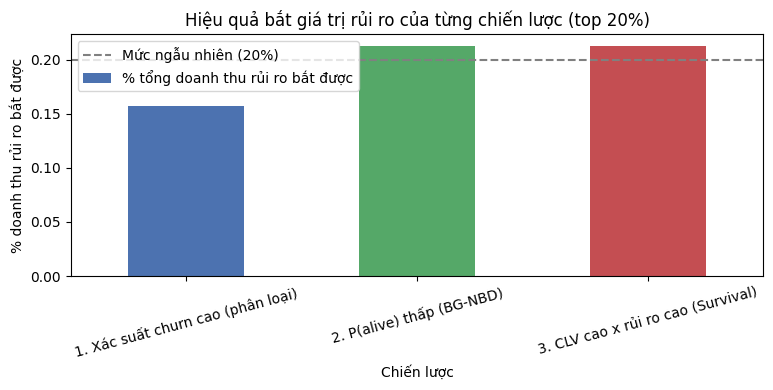


Chiến lược bắt được nhiều doanh thu rủi ro nhất: '3. CLV cao x rủi ro cao (Survival)' (21.3%, so với 20% nếu chọn ngẫu nhiên).


In [8]:
total_churned_value = (oot["customer_value"] * oot["churn"]).sum()

comparison_rows = []
for name, g in groups.items():
    churned_value_in_group = (g["customer_value"] * g["churn"]).sum()
    comparison_rows.append({
        "Chiến lược": name,
        "Số khách churn thực tế trong nhóm": int(g["churn"].sum()),
        "% tổng số khách churn bắt được": g["churn"].sum() / oot["churn"].sum(),
        "% tổng doanh thu rủi ro bắt được": churned_value_in_group / total_churned_value,
    })

comparison = pd.DataFrame(comparison_rows).set_index("Chiến lược")
display(comparison.style.format({
    "% tổng số khách churn bắt được": "{:.1%}", "% tổng doanh thu rủi ro bắt được": "{:.1%}",
}))

fig, ax = plt.subplots(figsize=(8, 4))
comparison["% tổng doanh thu rủi ro bắt được"].plot(ax=ax, kind="bar", color=["#4C72B0", "#55A868", "#C44E52"])
ax.axhline(0.20, color="gray", linestyle="--", label="Mức ngẫu nhiên (20%)")
ax.set_ylabel("% doanh thu rủi ro bắt được")
ax.set_title("Hiệu quả bắt giá trị rủi ro của từng chiến lược (top 20%)")
ax.tick_params(axis="x", rotation=15)
ax.legend()
plt.tight_layout()
plt.show()

winner = comparison["% tổng doanh thu rủi ro bắt được"].idxmax()
print(f"\nChiến lược bắt được nhiều doanh thu rủi ro nhất: '{winner}' "
      f"({comparison.loc[winner, '% tổng doanh thu rủi ro bắt được']:.1%}, so với 20% nếu chọn ngẫu nhiên).")


**Khuyến nghị:** chọn chiến lược có % doanh thu rủi ro bắt được cao nhất ở trên làm danh sách top 20% chính thức cho chiến dịch — đây là lựa chọn dựa trên số đo thực tế trên chính dữ liệu này, không phải suy luận chung chung. Phần mô phỏng ROI bên dưới dùng danh sách của chiến lược thắng cuộc.

In [9]:
top20 = groups[winner].copy()
k = len(top20)
total_value_at_risk = oot["customer_value"].mul(oot["churn"]).sum()
captured_value_at_risk = top20["customer_value"].mul(top20["churn"]).sum()

print(f"Chiến lược được chọn: {winner}")
print(f"Số khách hàng trong danh sách: {k:,} / {len(oot):,}")
print(f"Doanh thu thực sự mất vì churn mà nhóm này bắt được: {captured_value_at_risk:,.0f} đ "
      f"({captured_value_at_risk / total_value_at_risk:.1%} tổng doanh thu rủi ro thực tế)")


Chiến lược được chọn: 3. CLV cao x rủi ro cao (Survival)
Số khách hàng trong danh sách: 646 / 3,234
Doanh thu thực sự mất vì churn mà nhóm này bắt được: 210,085 đ (21.3% tổng doanh thu rủi ro thực tế)


## 4. Từ targeting đã kiểm chứng đến kịch bản ROI (không phải backtest)

Đến mục 3, mọi con số đều dựa trên **kết quả thật đã quan sát được**: model có chọn đúng người sắp churn hay không (decile-lift, capture@20%) được kiểm chứng bằng churn thật của cohort OOT — đó là một backtest hợp lệ, vì đây là câu hỏi **dự đoán** (predictive): "ai sẽ churn?".

Phần ROI dưới đây trả lời một câu hỏi khác hẳn — **nhân quả** (causal): "nếu can thiệp thì churn giảm bao nhiêu?". Dữ liệu này **chưa từng có một chiến dịch can thiệp nào thực sự xảy ra** (không ai từng nhận voucher, không có nhóm treated/control thật trong lịch sử), nên câu hỏi nhân quả đó **không thể backtest được từ dữ liệu quan sát thuần tuý** — dù dữ liệu có lớn cỡ nào. Cụ thể:

- **Việc "chọn ai" (top 20%) — đã backtest thật**, dùng lại đúng kết quả đã kiểm chứng ở mục 3.
- **Hiệu ứng can thiệp (`TREATMENT_EFFECT`) — KHÔNG backtest được**, chỉ là một giả định minh hoạ. "Nhóm đối chứng" dưới đây cũng chỉ là **random split mô phỏng lại thiết kế đo lường sẽ dùng khi chạy thật**, không phải một thử nghiệm đã từng xảy ra.
- Vì vậy **ROI bên dưới là một kịch bản có điều kiện** — *"nếu hiệu ứng can thiệp thật là X% thì ROI là Y%"* — không phải một con số đã được đo. Mục 4.2 thử nhiều mức X khác nhau thay vì chỉ tin vào một con số duy nhất. Để có `TREATMENT_EFFECT` thật, bắt buộc phải chạy một chiến dịch thật với nhóm đối chứng thật và đo uplift thật (xem mục 6).

**Giả định dùng cho kịch bản trung tâm ở mục 4.1** (thận trọng, không chọn số đẹp cho kết quả):
- `COST_PER_CONTACT = 25 đ` — cùng thang đơn vị với `amount` (đơn hàng trung bình ~58 đ).
- `TREATMENT_EFFECT = 15%` — MỘT giả định trong nhiều khả năng, không phải số đo được.
- Nhóm đối chứng mô phỏng: 10% danh sách mục tiêu, giữ lại không tiếp cận — thiết kế này nên được **giữ nguyên khi chạy chiến dịch thật**, để lần sau có dữ liệu treated/control thật thay cho giả định.

### 4.1. Kịch bản trung tâm (giả định `TREATMENT_EFFECT` = 15%)

So sánh cùng thước đo — doanh thu thực sự mất vì churn (`customer_value x churn`) — cho **Mass marketing (baseline hiện tại)** và **top 20% của cả 3 phương pháp** đã xây ở mục 1 (không chỉ phương pháp thắng cuộc ở mục 3): việc một phương pháp bắt được nhiều doanh thu rủi ro nhất (mục 3) không tự động đồng nghĩa nó có ROI/độ an toàn tài chính tốt nhất — hai câu hỏi này cần trả lời độc lập.

In [10]:
COST_PER_CONTACT = 25.0   # cùng thang đơn vị với cột "amount" trong dữ liệu giao dịch
TREATMENT_EFFECT = 0.15  # giả định trung tâm — xem mục 4.2 để biết độ nhạy với giả định này
CONTROL_FRACTION = 0.10

rng = np.random.default_rng(42)

def simulate_strategy(name, population: pd.DataFrame, targeted: pd.DataFrame):
    targeted = targeted.assign(value_at_risk=targeted["customer_value"] * targeted["churn"])
    n_targeted = len(targeted)
    is_control = rng.random(n_targeted) < CONTROL_FRACTION
    treated = targeted.loc[~is_control]
    control = targeted.loc[is_control]

    treated_value_at_risk = treated["value_at_risk"].sum()
    cost = len(treated) * COST_PER_CONTACT
    expected_value_retained = treated_value_at_risk * TREATMENT_EFFECT

    return {
        "strategy": name,
        "n_population": len(population),
        "n_targeted": n_targeted,
        "n_control": len(control),
        "value_at_risk_in_target": targeted["value_at_risk"].sum(),
        "treated_value_at_risk": treated_value_at_risk,  # dùng cho phân tích độ nhạy ở mục 4.2, không hiển thị ở bảng dưới
        "cost": cost,
        "expected_value_retained": expected_value_retained,
        "net_value": expected_value_retained - cost,
        "roi": (expected_value_retained - cost) / cost if cost > 0 else np.nan,
    }

# Mass marketing + top 20% của CẢ 3 phương pháp gốc (mục 1) — không chỉ phương pháp thắng cuộc.
results = pd.DataFrame([
    simulate_strategy("Mass marketing (100%)", oot, oot),
    simulate_strategy("1. Xác suất churn cao (phân loại), top 20%", oot, top20_classification),
    simulate_strategy("2. P(alive) thấp (BG-NBD), top 20%", oot, top20_bgnbd),
    simulate_strategy("3. CLV cao x rủi ro cao (Survival), top 20%", oot, top20_survival),
]).set_index("strategy")

display_cols = ["n_population", "n_targeted", "n_control", "value_at_risk_in_target", "cost", "expected_value_retained", "net_value", "roi"]
results_vn = results[display_cols].rename(columns={
    "n_population": "Tổng số khách hàng", "n_targeted": "Số khách được nhắm tới",
    "n_control": "Số khách đối chứng", "value_at_risk_in_target": "Doanh thu rủi ro trong nhóm nhắm tới",
    "cost": "Chi phí", "expected_value_retained": "Doanh thu giữ được (kỳ vọng, kịch bản 15%)",
    "net_value": "Lợi ích ròng (kịch bản 15%)", "roi": "ROI (kịch bản 15%)",
})
display(results_vn.style.format({
    "Doanh thu rủi ro trong nhóm nhắm tới": "{:,.0f} đ", "Chi phí": "{:,.0f} đ",
    "Doanh thu giữ được (kỳ vọng, kịch bản 15%)": "{:,.0f} đ", "Lợi ích ròng (kịch bản 15%)": "{:,.0f} đ",
    "ROI (kịch bản 15%)": "{:.1%}",
}))

,Tổng số khách hàng,Số khách được nhắm tới,Số khách đối chứng,Doanh thu rủi ro trong nhóm nhắm tới,Chi phí,"Doanh thu giữ được (kỳ vọng, kịch bản 15%)",Lợi ích ròng (kịch bản 15%),ROI (kịch bản 15%)
strategy,,,,,,,,
Mass marketing (100%),3234,3234,323,"986,789 đ","72,775 đ","133,114 đ","60,339 đ",82.9%
"1. Xác suất churn cao (phân loại), top 20%",3234,646,69,"154,739 đ","14,425 đ","20,995 đ","6,570 đ",45.5%
"2. P(alive) thấp (BG-NBD), top 20%",3234,646,62,"210,036 đ","14,600 đ","26,746 đ","12,146 đ",83.2%
"3. CLV cao x rủi ro cao (Survival), top 20%",3234,646,52,"210,085 đ","14,850 đ","28,269 đ","13,419 đ",90.4%


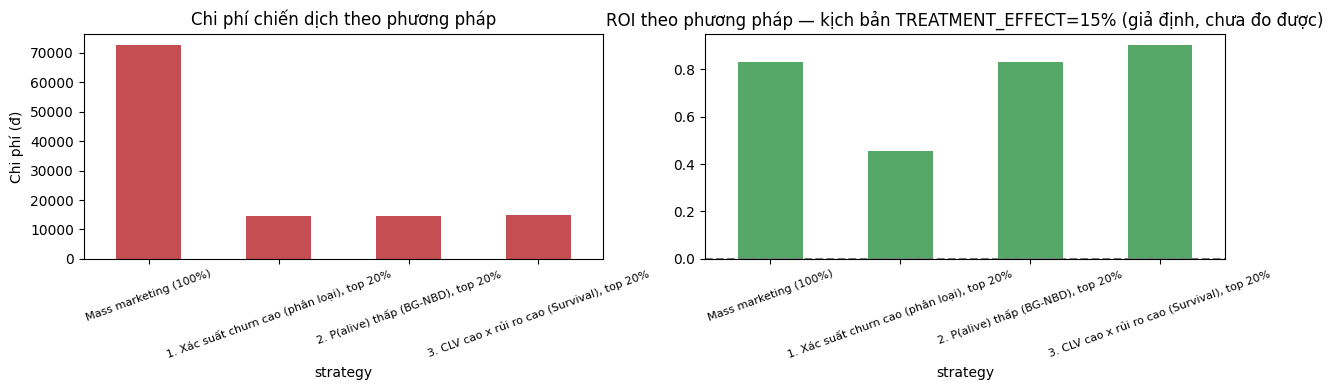

Trong kịch bản trung tâm (TREATMENT_EFFECT=15%): ROI cao nhất là '3. CLV cao x rủi ro cao (Survival), top 20%' đạt 90.4%
Phương pháp thắng cuộc ở mục 3 (bắt nhiều doanh thu rủi ro nhất, đã backtest thật) CŨNG là phương pháp có ROI cao nhất ở kịch bản này —
hai tiêu chí độc lập (value-capture thật và ROI giả định) đồng thuận, tăng độ tin cậy cho khuyến nghị.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
results["cost"].plot(ax=axes[0], kind="bar", color="#C44E52")
axes[0].set_title("Chi phí chiến dịch theo phương pháp")
axes[0].set_ylabel("Chi phí (đ)")
axes[0].tick_params(axis="x", rotation=20, labelsize=8)

results["roi"].plot(ax=axes[1], kind="bar", color="#55A868")
axes[1].set_title("ROI theo phương pháp — kịch bản TREATMENT_EFFECT=15% (giả định, chưa đo được)")
axes[1].axhline(0, color="gray", linestyle="--")
axes[1].tick_params(axis="x", rotation=20, labelsize=8)
plt.tight_layout()
plt.show()

best_roi = results["roi"].idxmax()
print(f"Trong kịch bản trung tâm (TREATMENT_EFFECT=15%): ROI cao nhất là '{best_roi}' đạt {results.loc[best_roi, 'roi']:.1%}")

winner_roi_row = [i for i in results.index if winner.split(".")[0] == i.split(".")[0] and "Mass" not in i][0]
if winner_roi_row == best_roi:
    print(f"Phương pháp thắng cuộc ở mục 3 (bắt nhiều doanh thu rủi ro nhất, đã backtest thật) CŨNG là phương pháp có ROI cao nhất ở kịch bản này —")
    print("hai tiêu chí độc lập (value-capture thật và ROI giả định) đồng thuận, tăng độ tin cậy cho khuyến nghị.")
else:
    print(f"Lưu ý: phương pháp thắng cuộc ở mục 3 ('{winner}') KHÔNG phải phương pháp có ROI cao nhất ở kịch bản 15% này ('{best_roi}') —")
    print("hai tiêu chí không đồng thuận, xem thêm phân tích độ nhạy ở mục 4.2 trước khi kết luận.")

### 4.2. Kịch bản trung tâm nhạy cảm thế nào với giả định `TREATMENT_EFFECT`?

Với công thức đang dùng, ROI của mỗi chiến lược là hàm **tuyến tính** theo `TREATMENT_EFFECT` (mọi thứ khác đã cố định một khi nhóm treated/control được chọn) — nên có thể tính chính xác, không cần đoán:

- **Hiệu ứng can thiệp tối thiểu để hoà vốn** (ROI = 0%) cho từng chiến lược — chiến lược nào cần hiệu ứng thật *thấp hơn* mới hoà vốn là chiến lược **rủi ro thấp hơn** trước sai số của giả định, bất kể ROI ở kịch bản 15% cao hay thấp.
- ROI thay đổi ra sao nếu hiệu ứng can thiệp thật khác 15% — có thể cao hơn, có thể thấp hơn, hoặc thậm chí âm.

,Hiệu ứng can thiệp tối thiểu để hoà vốn
strategy,
Mass marketing (100%),8.2%
"1. Xác suất churn cao (phân loại), top 20%",10.3%
"2. P(alive) thấp (BG-NBD), top 20%",8.2%
"3. CLV cao x rủi ro cao (Survival), top 20%",7.9%


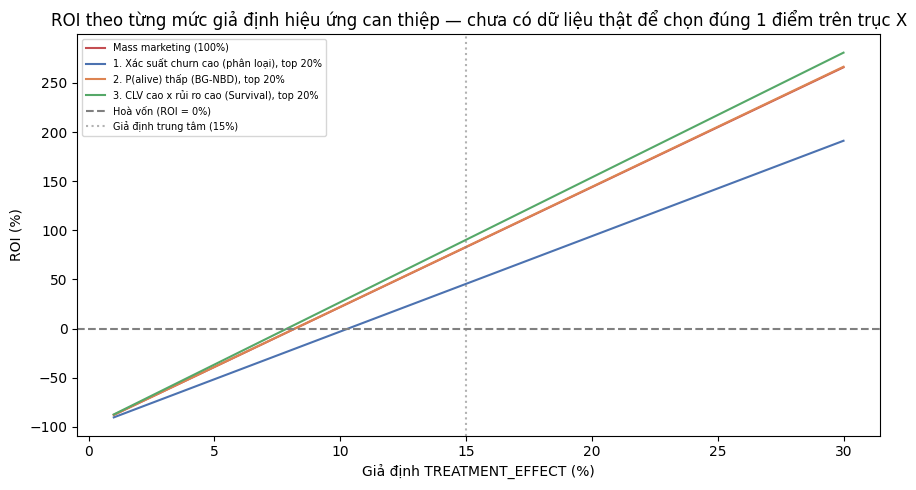

Phương pháp có hiệu ứng can thiệp tối thiểu để hoà vốn THẤP NHẤT (rủi ro thấp nhất trước sai số giả định): '3. CLV cao x rủi ro cao (Survival), top 20%' (cần thật ≥ 7.9%).
Đây là góc nhìn bổ sung cho ROI ở kịch bản 15% — một phương pháp có thể có ROI cao ở 15% nhưng
cũng cần hiệu ứng thật cao hơn mới hoà vốn, tức rủi ro hơn nếu giả định 15% hoá ra lạc quan quá mức.


In [12]:
results["breakeven_treatment_effect"] = results["cost"] / results["treated_value_at_risk"]

breakeven_vn = results[["breakeven_treatment_effect"]].rename(
    columns={"breakeven_treatment_effect": "Hiệu ứng can thiệp tối thiểu để hoà vốn"}
)
display(breakeven_vn.style.format({"Hiệu ứng can thiệp tối thiểu để hoà vốn": "{:.1%}"}))

treatment_effect_range = np.linspace(0.01, 0.30, 30)
fig, ax = plt.subplots(figsize=(9, 5))
palette = ["#C44E52", "#4C72B0", "#DD8452", "#55A868"]
for name, color in zip(results.index, palette):
    cost = results.loc[name, "cost"]
    tvar = results.loc[name, "treated_value_at_risk"]
    roi_curve = (tvar * treatment_effect_range - cost) / cost
    ax.plot(treatment_effect_range * 100, roi_curve * 100, label=name, color=color)

ax.axhline(0, color="gray", linestyle="--", label="Hoà vốn (ROI = 0%)")
ax.axvline(15, color="gray", linestyle=":", alpha=0.6, label="Giả định trung tâm (15%)")
ax.set_xlabel("Giả định TREATMENT_EFFECT (%)")
ax.set_ylabel("ROI (%)")
ax.set_title("ROI theo từng mức giả định hiệu ứng can thiệp — chưa có dữ liệu thật để chọn đúng 1 điểm trên trục X")
ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

lowest_breakeven = results["breakeven_treatment_effect"].idxmin()
print(f"Phương pháp có hiệu ứng can thiệp tối thiểu để hoà vốn THẤP NHẤT (rủi ro thấp nhất trước sai số giả định): '{lowest_breakeven}' "
      f"(cần thật ≥ {results.loc[lowest_breakeven, 'breakeven_treatment_effect']:.1%}).")
print("Đây là góc nhìn bổ sung cho ROI ở kịch bản 15% — một phương pháp có thể có ROI cao ở 15% nhưng")
print("cũng cần hiệu ứng thật cao hơn mới hoà vốn, tức rủi ro hơn nếu giả định 15% hoá ra lạc quan quá mức.")

## 5. Chính sách tiếp cận — nửa còn lại của bài toán "over-treatment"

Giới hạn phạm vi tiếp cận ở top 20% chính là câu trả lời trực tiếp cho vấn đề over-treatment nêu trong bài toán kinh doanh: 80% khách hàng *hoàn toàn không* bị chiến dịch này làm phiền, so với 100% nếu chạy mass-marketing. Với tổ chức có nhiều chiến dịch cùng lúc, nguyên tắc này cần đi xa hơn: một khách hàng lọt top 20% của *chiến dịch này* nên được đối chiếu với danh sách mục tiêu của các chiến dịch khác đang chạy và giới hạn tần suất tiếp cận/khách hàng trước khi thực sự liên hệ, để nhóm "giá trị cao - có nguy cơ rời bỏ" không bị mọi đội cùng nhắm tới một lúc.

## 6. Tóm tắt khuyến nghị

| Chiến lược | Cơ chế | Độ chính xác trong nhóm (thực tế có churn) | Nhược điểm |
|---|---|---|---|
| 1. Xác suất churn cao (phân loại) | Chỉ dùng tín hiệu rủi ro (RFM_v1 + LightGBM) | 79.7% | Không tính đến giá trị khách hàng — bắt được nhiều khách churn nhưng giá trị thấp |
| 2. P(alive) thấp (BG-NBD) | Xác suất thuần hành vi, không cần nhãn churn | 64.4% | Độ chính xác thấp nhất trong 3 chiến lược trên dữ liệu này |
| **3. CLV cao × rủi ro cao (Survival)** | **Kết hợp rủi ro ngắn hạn (Weibull AFT) và giá trị còn lại kỳ vọng (Gamma-Gamma)** | **96.7%** | Phụ thuộc chất lượng ước lượng CLV còn lại; mô hình phức tạp hơn, khó giải thích hơn |

**Phần targeting (chọn ai): đã kiểm chứng bằng dữ liệu thật.** Chiến lược thắng cuộc ở mục 3 được chọn dựa trên số đo thực tế (% doanh thu rủi ro thực sự bắt được), không phải giả định — đây là điểm khác biệt so với việc chỉ chọn theo lý thuyết. Danh sách top 20% của chiến lược này nên thay thế danh sách giữ chân khách hàng kiểu mass-marketing hiện tại.

**Phần ROI (can thiệp có đáng tiền không): CHƯA thể kết luận bằng dữ liệu này.** Mục 4 tính ROI cho Mass marketing và cả 3 phương pháp gốc (không chỉ phương pháp thắng cuộc ở mục 3) — con số này chỉ đúng dưới giả định `TREATMENT_EFFECT=15%` chưa từng được đo. Điều duy nhất có thể nói chắc từ mục 4.2: phương pháp nào có **hiệu ứng can thiệp tối thiểu để hoà vốn thấp nhất** là lựa chọn an toàn hơn trước sai số của giả định — bất kể ROI ở kịch bản 15% trông đẹp hay không. Nếu phương pháp đó trùng với phương pháp thắng cuộc ở mục 3 (bắt nhiều doanh thu rủi ro thật nhất), hai tiêu chí độc lập đồng thuận — cơ sở khuyến nghị vững hơn một tiêu chí đơn lẻ.

**Để biến giả định thành số đo được:** phải chạy một chiến dịch thật, giữ đúng thiết kế nhóm đối chứng đã mô phỏng ở mục 4 (10% không tiếp cận), rồi đo `TREATMENT_EFFECT` thật = chênh lệch tỷ lệ churn giữa nhóm treated và control. Đó cũng là bước tự nhiên tiến tới một **mô hình uplift** (dự đoán phản hồi *gia tăng* do được can thiệp, thay vì chỉ dự đoán rủi ro churn) một khi có vài chu kỳ dữ liệu treated/control thật.